# E06 — does static soil explain the field effect?

Continues `03-the-field-effect.ipynb`, which established the object: a per-site constant worth
**34.5%** of the variance of `forward_z`, **entirely within-cluster** (between-cluster ICC 0.0000),
and unexplained by anything in the panel (elevation r² 0.017, latitude 0.020, longitude 0.034).

E06 asks whether **soil** is the missing explanation. If it were, the field effect would be a
physical site property rather than an unmodelled per-field idiosyncrasy, and the whole `level_z`
line of work would be interpretable.

**Data.** SoilGrids v2.0 (ISRIC), 7 properties × 2 depths, fetched to `.cache/soilgrids/` by
`experiments/E06-soil/fetch_soilgrids.py`; joined to the field effect by
`experiments/E06-soil/build_and_regress.py`. This notebook reads that experiment's committed
result and re-derives the headline figure rather than restating it.

**Sources**
* SoilGrids v2.0 — Poggio et al. (2021), *SOIL* 7:217–240,
  [doi:10.5194/soil-7-217-2021](https://doi.org/10.5194/soil-7-217-2021) — **[UNVERIFIED]**
* Cluster fixed effects via within-group demeaning — Frisch & Waugh (1933) / Lovell (1963),
  see [docs/CONCEPTS.md](../docs/CONCEPTS.md) — **[UNVERIFIED]**
* Permutation testing — Good, *Permutation, Parametric and Bootstrap Tests of Hypotheses*;
  the construction used here is standard, not borrowed from a specific paper.
* Field-effect ICC, and the elevation/lat/lon nulls — **measurements on this repository**,
  `experiments/E01_variance_decomposition.out` and `notebooks/03-the-field-effect.ipynb`.

## 1. Setup

In [1]:
import json, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '../experiments/E06-soil')
import build_and_regress as E
from argotech.lab.estimand.targets import alpha_hat

res = json.load(open('../experiments/E06-soil/e06_result.json'))
print('coverage:', res['n_sites_with_soil'], '/', res['n_sites_total'], 'sites')
print('git sha :', res['git_sha'], '| seed', res['seed'])

coverage: 119 / 122 sites
git sha : d1e6e2f | seed 20260829


## 2. Coverage — is the gap cluster-structured?

Three sites of 122 lack a complete soil row. That only matters if the gaps concentrate in one
cluster, which would make the within-cluster comparison uneven. They do not.

In [2]:
cov = pd.DataFrame(res['coverage_by_cluster'])
cov['missing'] = cov['count'] - cov['sum']
display(cov)
print(f"total missing: {int(cov['missing'].sum())} of {int(cov['count'].sum())}")

,cluster,sum,count,missing
0,Benue_River_Basin,26,27,1
1,Kaduna_Grain_Belt,31,32,1
2,Kano_Sudan_Savannah,31,32,1
3,Kenya_Rift_Valley,31,31,0


total missing: 3 of 122


## 3. Rebuild the join

Reusing the experiment's own `load_soil_row` so the notebook cannot drift from the script.

In [3]:
panel = pd.read_parquet('../data/training_set.parquet')
a = alpha_hat(panel, column='ndvi_z_peer', unit='site_id', min_history=5)
se = (panel.assign(alpha=a).dropna(subset=['alpha'])
      .groupby(['site_id','cluster']).alpha.mean().reset_index())
site = (panel[['site_id','latitude','longitude','elevation']].drop_duplicates('site_id')
        .merge(se, on='site_id'))
soil = {s: E.load_soil_row(s) for s in site.site_id}
soil = {s: r for s, r in soil.items() if r is not None}
sdf = pd.DataFrame.from_dict(soil, orient='index')
xcols = list(sdf.columns)
m = site.merge(sdf, left_on='site_id', right_index=True, how='inner')
print(f'{len(m)} sites x {len(xcols)} covariates')
m.head(3)

119 sites x 14 covariates


,site_id,latitude,longitude,elevation,cluster,alpha,clay_0-5cm,clay_5-15cm,sand_0-5cm,sand_5-15cm,silt_0-5cm,silt_5-15cm,soc_0-5cm,soc_5-15cm,phh2o_0-5cm,phh2o_5-15cm,cec_0-5cm,cec_5-15cm,bdod_0-5cm,bdod_5-15cm
0,Kaduna_Grain_Belt-000,11.3375,7.9667,693.0,Kaduna_Grain_Belt,0.132649,15.9,18.3,47.5,46.4,36.7,35.3,11.0,7.4,6.4,6.3,9.3,8.8,1.33,1.35
1,Kaduna_Grain_Belt-001,10.2812,8.3667,1047.0,Kaduna_Grain_Belt,0.951306,19.8,20.8,55.5,55.0,24.8,24.2,29.4,19.2,5.8,5.8,10.8,10.8,1.25,1.27
2,Kaduna_Grain_Belt-002,10.9313,7.3444,590.0,Kaduna_Grain_Belt,2.087160,14.7,15.1,58.6,56.7,26.7,28.3,9.1,8.6,6.1,6.1,7.0,6.8,1.34,1.35


## 4. Per-covariate within-cluster correlation

Each bar is a **single** covariate, so it is barely inflated (one predictor, 119 sites). The dashed
line is the best null from notebook 03 — longitude, r² 0.034. Soil organic carbon and bulk density
clear it comfortably; CEC and silt do not clear it at all.

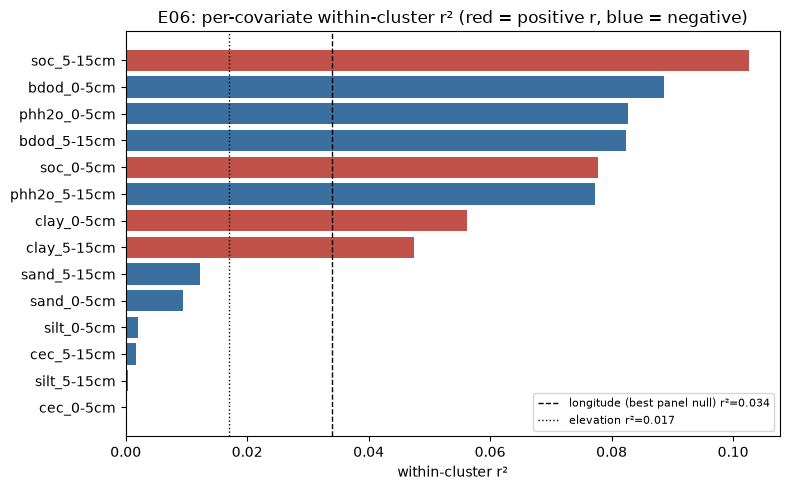

,covariate,r,r2
0,soc_5-15cm,0.320303,0.102594
1,bdod_0-5cm,-0.297753,0.088657
2,phh2o_0-5cm,-0.287637,0.082735
3,bdod_5-15cm,-0.286935,0.082332
4,soc_0-5cm,0.278769,0.077712
5,phh2o_5-15cm,-0.278020,0.077295


In [4]:
per = pd.DataFrame(res['per_covariate_r2']).sort_values('r2', ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c0524a' if v > 0 else '#3b6fa0' for v in per['r']]
ax.barh(per['covariate'], per['r2'], color=colors)
for null, lab, ls in [(0.034,'longitude (best panel null)','--'), (0.017,'elevation',':')]:
    ax.axvline(null, color='k', ls=ls, lw=1, label=f'{lab} r²={null}')
ax.set_xlabel('within-cluster r²'); ax.legend(loc='lower right', fontsize=8)
ax.set_title('E06: per-covariate within-cluster r² (red = positive r, blue = negative)')
fig.tight_layout(); plt.show()
per.sort_values('r2', ascending=False).head(6)

## 5. The correction that matters: in-sample vs out-of-fold

The joint fit uses **14 collinear covariates on 119 sites**. In-sample R² is inflated by
construction, and bootstrapping it does not help — resampling sites and re-scoring in-sample gives
an interval around an *optimistic* estimator.

The permutation null makes the inflation visible: shuffle the field effect **within cluster**, so
the covariates carry no information about the target, and refit. Whatever R² comes back is pure
overfitting.

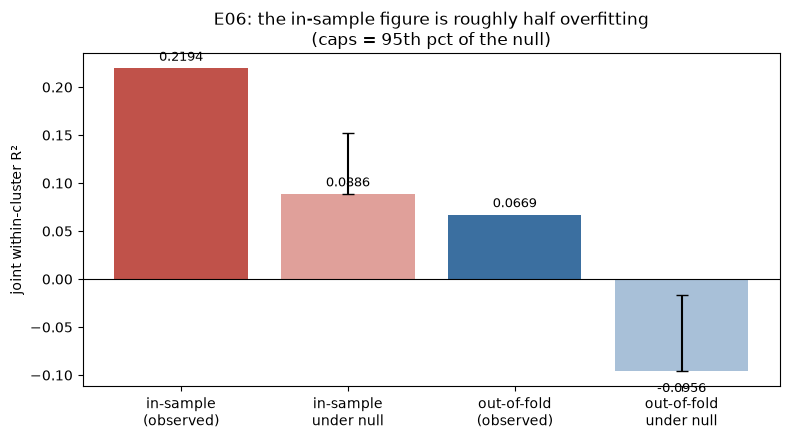

in-sample observed      : 0.2194
in-sample under null    : 0.0886  (95th pct 0.1517)
OUT-OF-FOLD observed    : 0.0669   <-- the honest figure
out-of-fold under null  : -0.0956  (95th pct -0.0168)
permutation p-value     : 0.000


In [5]:
null = res['null_permutation']
labels = ['in-sample\n(observed)', 'in-sample\nunder null', 'out-of-fold\n(observed)', 'out-of-fold\nunder null']
vals   = [res['joint_r2_insample_diagnostic'], null['insample_mean'],
          res['joint_r2_cv'], null['cv_mean']]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, vals, color=['#c0524a', '#e0a09a', '#3b6fa0', '#a8c0d8'])
ax.axhline(0, color='k', lw=0.8)
ax.errorbar(1, null['insample_mean'], yerr=[[0],[null['insample_p95']-null['insample_mean']]],
            fmt='none', ecolor='k', capsize=4)
ax.errorbar(3, null['cv_mean'], yerr=[[0],[null['cv_p95']-null['cv_mean']]],
            fmt='none', ecolor='k', capsize=4)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v + (0.008 if v>=0 else -0.022), f'{v:.4f}',
            ha='center', fontsize=9)
ax.set_ylabel('joint within-cluster R²')
ax.set_title('E06: the in-sample figure is roughly half overfitting\n(caps = 95th pct of the null)')
fig.tight_layout(); plt.show()

print(f"in-sample observed      : {res['joint_r2_insample_diagnostic']:.4f}")
print(f"in-sample under null    : {null['insample_mean']:.4f}  (95th pct {null['insample_p95']:.4f})")
print(f"OUT-OF-FOLD observed    : {res['joint_r2_cv']:.4f}   <-- the honest figure")
print(f"out-of-fold under null  : {null['cv_mean']:.4f}  (95th pct {null['cv_p95']:.4f})")
print(f"permutation p-value     : {res['permutation_p_value_cv']:.3f}")

## 6. Where the permutation test and the bootstrap disagree — and why both are right

They answer different questions, and reporting only one would mislead in opposite directions.

* **Permutation p = 0.000** — *could this arise if soil carried no signal?* No.
* **Bootstrap CI crosses zero** — *how well do 119 sites pin down the magnitude?* Poorly.

The direction is established; the magnitude is not.

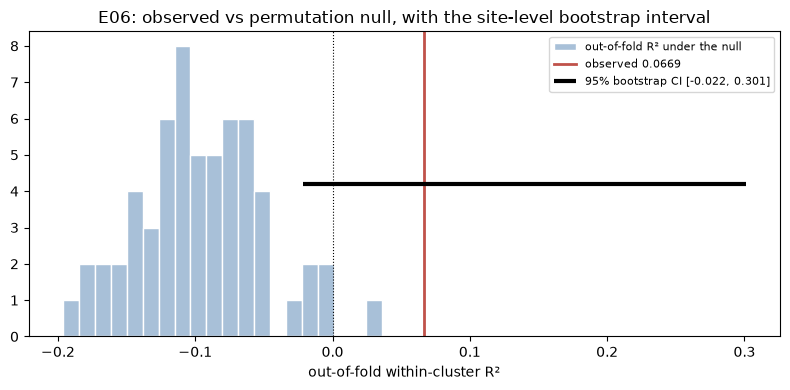

observed 0.0669 exceeds 100.0% of null draws


In [6]:
lo, hi = res['joint_r2_cv_bootstrap_ci']
cvnull = np.array(null['cv_values'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cvnull, bins=20, color='#a8c0d8', edgecolor='w', label='out-of-fold R² under the null')
ax.axvline(res['joint_r2_cv'], color='#c0524a', lw=2, label=f"observed {res['joint_r2_cv']:.4f}")
ax.hlines(ax.get_ylim()[1]*0.5, lo, hi, color='k', lw=3, label=f'95% bootstrap CI [{lo:.3f}, {hi:.3f}]')
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('out-of-fold within-cluster R²'); ax.legend(fontsize=8)
ax.set_title('E06: observed vs permutation null, with the site-level bootstrap interval')
fig.tight_layout(); plt.show()
print(f'observed {res["joint_r2_cv"]:.4f} exceeds {(cvnull < res["joint_r2_cv"]).mean():.1%} of null draws')

## 7. What this answers

Soil explains **~6.7%** of the within-cluster field effect out of fold. The field effect is 34.5% of
total variance, so that is about **2.3% of total variance** — comparable to the panel's existing ~3%,
and it leaves roughly **93% of the field effect unexplained**.

**So the answer to E06 is: no, not substantially.** Soil organic carbon is a real and reproducible
correlate (`soc_5-15cm`, r = +0.320, univariate and so barely inflated), but the joint model does not
recover the field effect.

Two consequences, both from
[the joining spec](../docs/superpowers/specs/2026-08-29-dataset-joining-design.md):

1. **§2** — static covariates are admissible only for `level_z`. Since they do not explain the field
   effect, they cannot help within-field ranking either; there is no route by which soil improves the
   `within_*` estimands.
2. **§8** — the open question resolves toward the uncomfortable branch: with the field effect still
   unexplained, `level_z` skill should be read as *the model has learned which fields are bad*,
   not as agronomic prediction.